# Titanic Survival Prediction

## Feature Engineering, Model Evaluation and Hyperparameter Optimization

This notebook demonstrates a complete machine learning workflow suitable for a professional GitHub portfolio.

### Objectives
- Explore the Titanic passenger dataset.
- Engineer useful numerical and categorical features.
- Build reusable Scikit-Learn preprocessing pipelines.
- Compare multiple classification models.
- Tune the best model using GridSearchCV.
- Evaluate the final model using business-relevant metrics.
- Interpret feature importance.


## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## 2. Load Dataset

The notebook first checks for `../data/titanic.csv`.

If the file is missing, it attempts to load Seaborn's built-in Titanic dataset.


In [2]:
data_path = Path("../data/titanic.csv")

if data_path.exists():
    df = pd.read_csv(data_path)
    print("Loaded local dataset:", data_path)
else:
    try:
        df = sns.load_dataset("titanic")
        print("Loaded Seaborn Titanic dataset.")
    except Exception as e:
        raise FileNotFoundError(
            "Could not find ../data/titanic.csv and could not load Seaborn's Titanic dataset. "
            "Please place titanic.csv inside the data folder."
        ) from e

df.head()


Loaded Seaborn Titanic dataset.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Data Overview

In [3]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing_values = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_values["missing_percentage"] = (missing_values["missing_count"] / len(df) * 100).round(2)
missing_values.head(15)


,missing_count,missing_percentage
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
survived,0,0.00
pclass,0,0.00
sex,0,0.00
sibsp,0,0.00
parch,0,0.00
fare,0,0.00


## 4. Exploratory Data Analysis

This section helps understand survival patterns before model training.


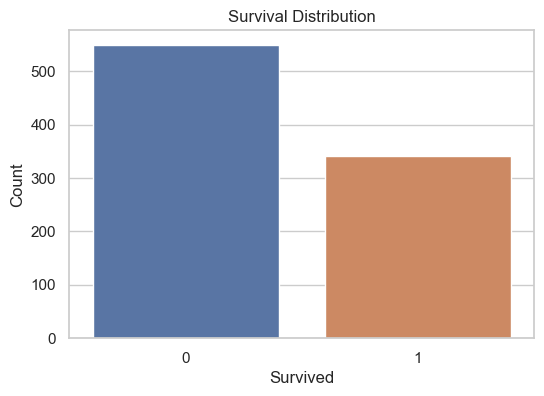

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="survived" if "survived" in df.columns else "Survived")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()


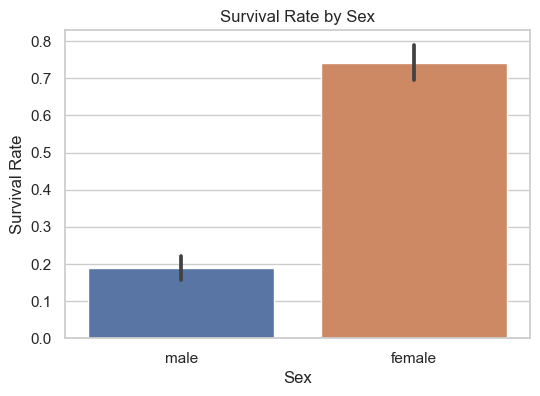

In [7]:
sex_col = "sex" if "sex" in df.columns else "Sex"
target_col = "survived" if "survived" in df.columns else "Survived"

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x=sex_col, y=target_col)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()


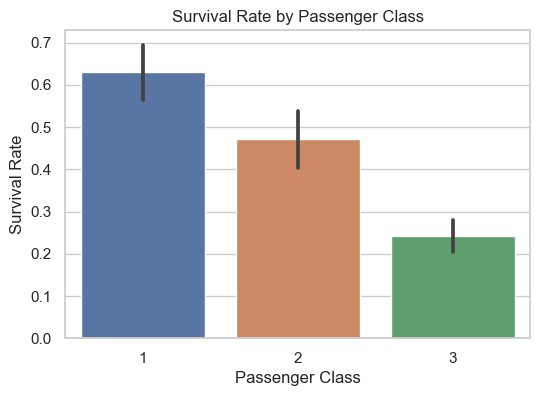

In [8]:
pclass_col = "pclass" if "pclass" in df.columns else "Pclass"

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x=pclass_col, y=target_col)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


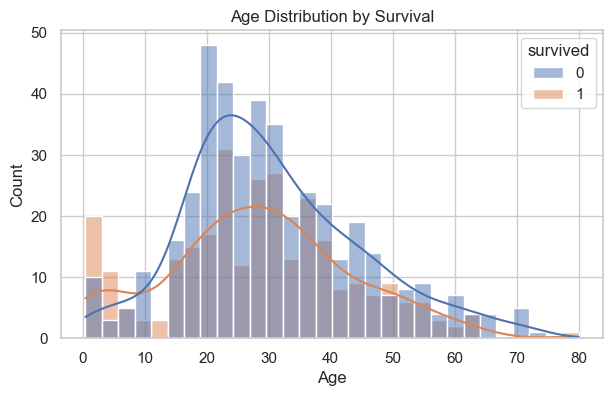

In [9]:
age_col = "age" if "age" in df.columns else "Age"

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x=age_col, hue=target_col, kde=True, bins=30)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.show()


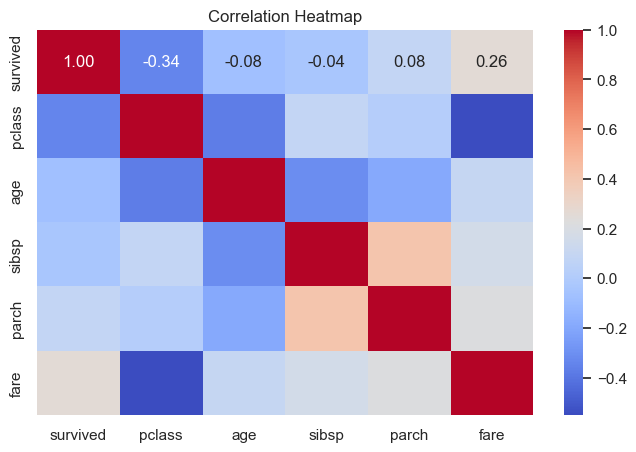

In [10]:
plt.figure(figsize=(8, 5))
numeric_corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(numeric_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 5. Feature Selection and Cleaning

The model uses common Titanic features.

For Seaborn's dataset, column names are lowercase.  
For Kaggle-style Titanic datasets, column names are often title case.


In [11]:
# Standardize column names to make the workflow work with both Seaborn and Kaggle-style Titanic data.
df_model = df.copy()
df_model.columns = [col.lower() for col in df_model.columns]

required_columns = ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
available_columns = [col for col in required_columns if col in df_model.columns]

df_model = df_model[available_columns].copy()

# Basic feature engineering
if {"sibsp", "parch"}.issubset(df_model.columns):
    df_model["family_size"] = df_model["sibsp"] + df_model["parch"] + 1
    df_model["is_alone"] = (df_model["family_size"] == 1).astype(int)

df_model.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,2,0
1,1,1,female,38.0,1,0,71.2833,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,1
3,1,1,female,35.0,1,0,53.1000,S,2,0
4,0,3,male,35.0,0,0,8.0500,S,1,1


In [12]:
target = "survived"

numeric_features = [col for col in ["age", "fare", "sibsp", "parch", "family_size", "is_alone"] if col in df_model.columns]
categorical_features = [col for col in ["pclass", "sex", "embarked"] if col in df_model.columns]

X = df_model.drop(columns=[target])
y = df_model[target]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'fare', 'sibsp', 'parch', 'family_size', 'is_alone']
Categorical features: ['pclass', 'sex', 'embarked']


## 6. Train-Test Split

A hold-out test set is used for final evaluation after cross-validation and tuning.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (712, 9)
Test set: (179, 9)


## 7. Build Preprocessing Pipeline

In [14]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])


## 8. Model Comparison with Cross-Validation

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = []

for model_name, classifier in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=False
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("ROC-AUC", ascending=False)
cv_results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.820329,0.810024,0.692593,0.745479,0.878337
0,Logistic Regression,0.795036,0.750504,0.699865,0.721579,0.855898
1,Random Forest,0.789461,0.729166,0.714613,0.721605,0.843882


## 9. Hyperparameter Tuning with GridSearchCV

Random Forest is tuned because it usually performs well on tabular classification tasks and provides feature importance.


In [16]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best ROC-AUC:", grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)


Best ROC-AUC: 0.8691369415154682
Best parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


## 10. Final Model Evaluation

In [17]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

final_metrics = pd.DataFrame([{
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}])

final_metrics


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.810056,0.857143,0.608696,0.711864,0.839723


In [18]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.79      0.94      0.86       110
           1       0.86      0.61      0.71        69

    accuracy                           0.81       179
   macro avg       0.82      0.77      0.79       179
weighted avg       0.82      0.81      0.80       179



## 11. Confusion Matrix

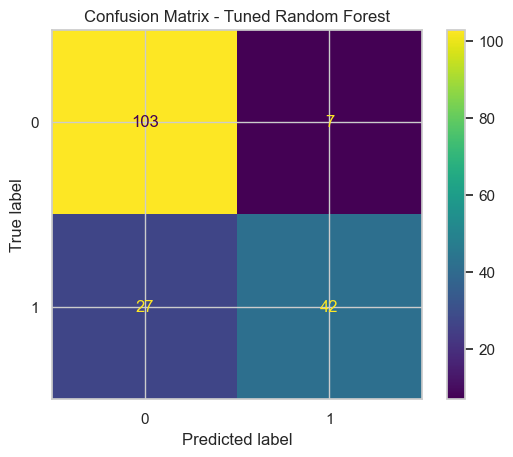

In [19]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()


## 12. ROC Curve

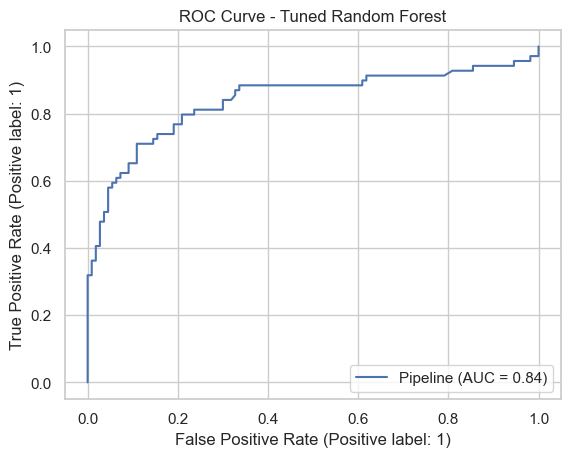

In [20]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Tuned Random Forest")
plt.show()


## 13. Feature Importance

This section explains which engineered and original features contributed most to the model.


In [21]:
preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier_fitted = best_model.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = classifier_fitted.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(15)


,Feature,Importance
9,categorical__sex_female,0.256913
10,categorical__sex_male,0.253816
1,numeric__fare,0.127915
0,numeric__age,0.088139
8,categorical__pclass_3,0.078342
6,categorical__pclass_1,0.048756
4,numeric__family_size,0.044530
2,numeric__sibsp,0.019957
7,categorical__pclass_2,0.018163
3,numeric__parch,0.017849


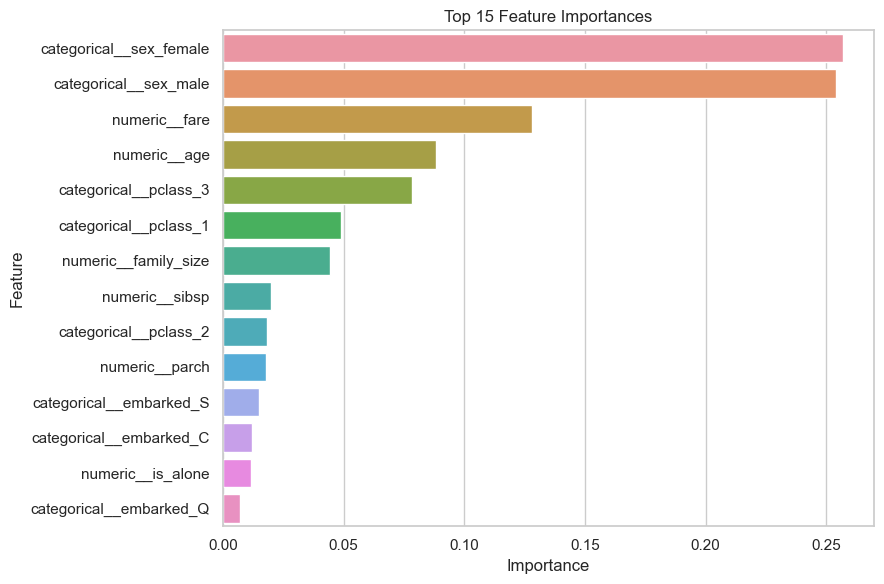

In [22]:
plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 14. Conclusion

### Key Findings
- Passenger sex, class, fare, and age are usually important predictors of survival.
- Feature engineering improved the model by adding family-related variables.
- Random Forest performed strongly after hyperparameter tuning.
- ROC-AUC, F1 Score, Precision, and Recall provide a more complete evaluation than accuracy alone.

### Portfolio Value
This project demonstrates practical skills expected in junior AI and machine learning roles:
- Building reusable ML pipelines.
- Evaluating models responsibly.
- Explaining model behavior using feature importance.
- Communicating results clearly.
